# 02 - Tarea guiada: métricas y evaluación por archivo

En esta tarea **no se usa `course_utils.metrics`**. Primero defines tus propias funciones de métricas y luego las usas para construir una evaluación completa por archivo y por modelo.

Puedes usar `course_utils.data`, `course_utils.palette` y `course_utils.plotting`, pero las métricas son tu responsabilidad.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from course_utils.data import (
    SAMPLE_FILES,
    LEAD_MINUTES,
    get_paths,
    load_sample,
    split_sequence,
    load_prediction,
    make_persistence_prediction,
)
from course_utils.palette import apply_course_style, RAIN_LEVELS
from course_utils.plotting import plot_event_grid, plot_target_prediction_panel, plot_rmse_bias, plot_csi_by_threshold

apply_course_style()
paths = get_paths(PROJECT_ROOT)

THRESHOLDS = [0.5, 2.0, 5.0, 10.0]
THRESHOLD_LABELS = {
    0.5: "lluvia ligera",
    2.0: "lluvia moderada",
    5.0: "lluvia fuerte",
    10.0: "lluvia intensa",
}

print(f"Proyecto: {paths.root}")
print(f"Muestras: {paths.sample_dir}")

Proyecto: C:\Users\Pedro Lopevia\Escritorio\S04-nowcasting-course-lab
Muestras: C:\Users\Pedro Lopevia\Escritorio\S04-nowcasting-course-lab\data\samples


## 1. Cargar un caso

Elige una muestra. Si existen predicciones de CasCast/EarthFormer se cargarán; si no, se usará persistencia.

In [2]:
sample_name = SAMPLE_FILES[0]  # TODO: prueba otros casos
sequence = load_sample(sample_name, paths)
inputs, target = split_sequence(sequence)
prediction, prediction_source = load_prediction(sample_name, inputs, paths)

print(sample_name)
print("Fuente:", prediction_source)
print("inputs:", inputs.shape, "target:", target.shape, "prediction:", prediction.shape)
print("Niveles de color mm/h:", RAIN_LEVELS)

barranca_seq_20240426_2000_patch_04_rain_rate.npy
Fuente: persistencia
inputs: (13, 128, 128) target: (12, 128, 128) prediction: (12, 128, 128)
Niveles de color mm/h: [0.05, 0.5, 2.0, 5.0, 10.0, 20.0, 30.0, 50.0, 60.0]


## 2. Visualización inicial

Responde: ¿hacia dónde se mueve la tormenta?, ¿la predicción conserva los máximos?, ¿hay desplazamiento espacial?

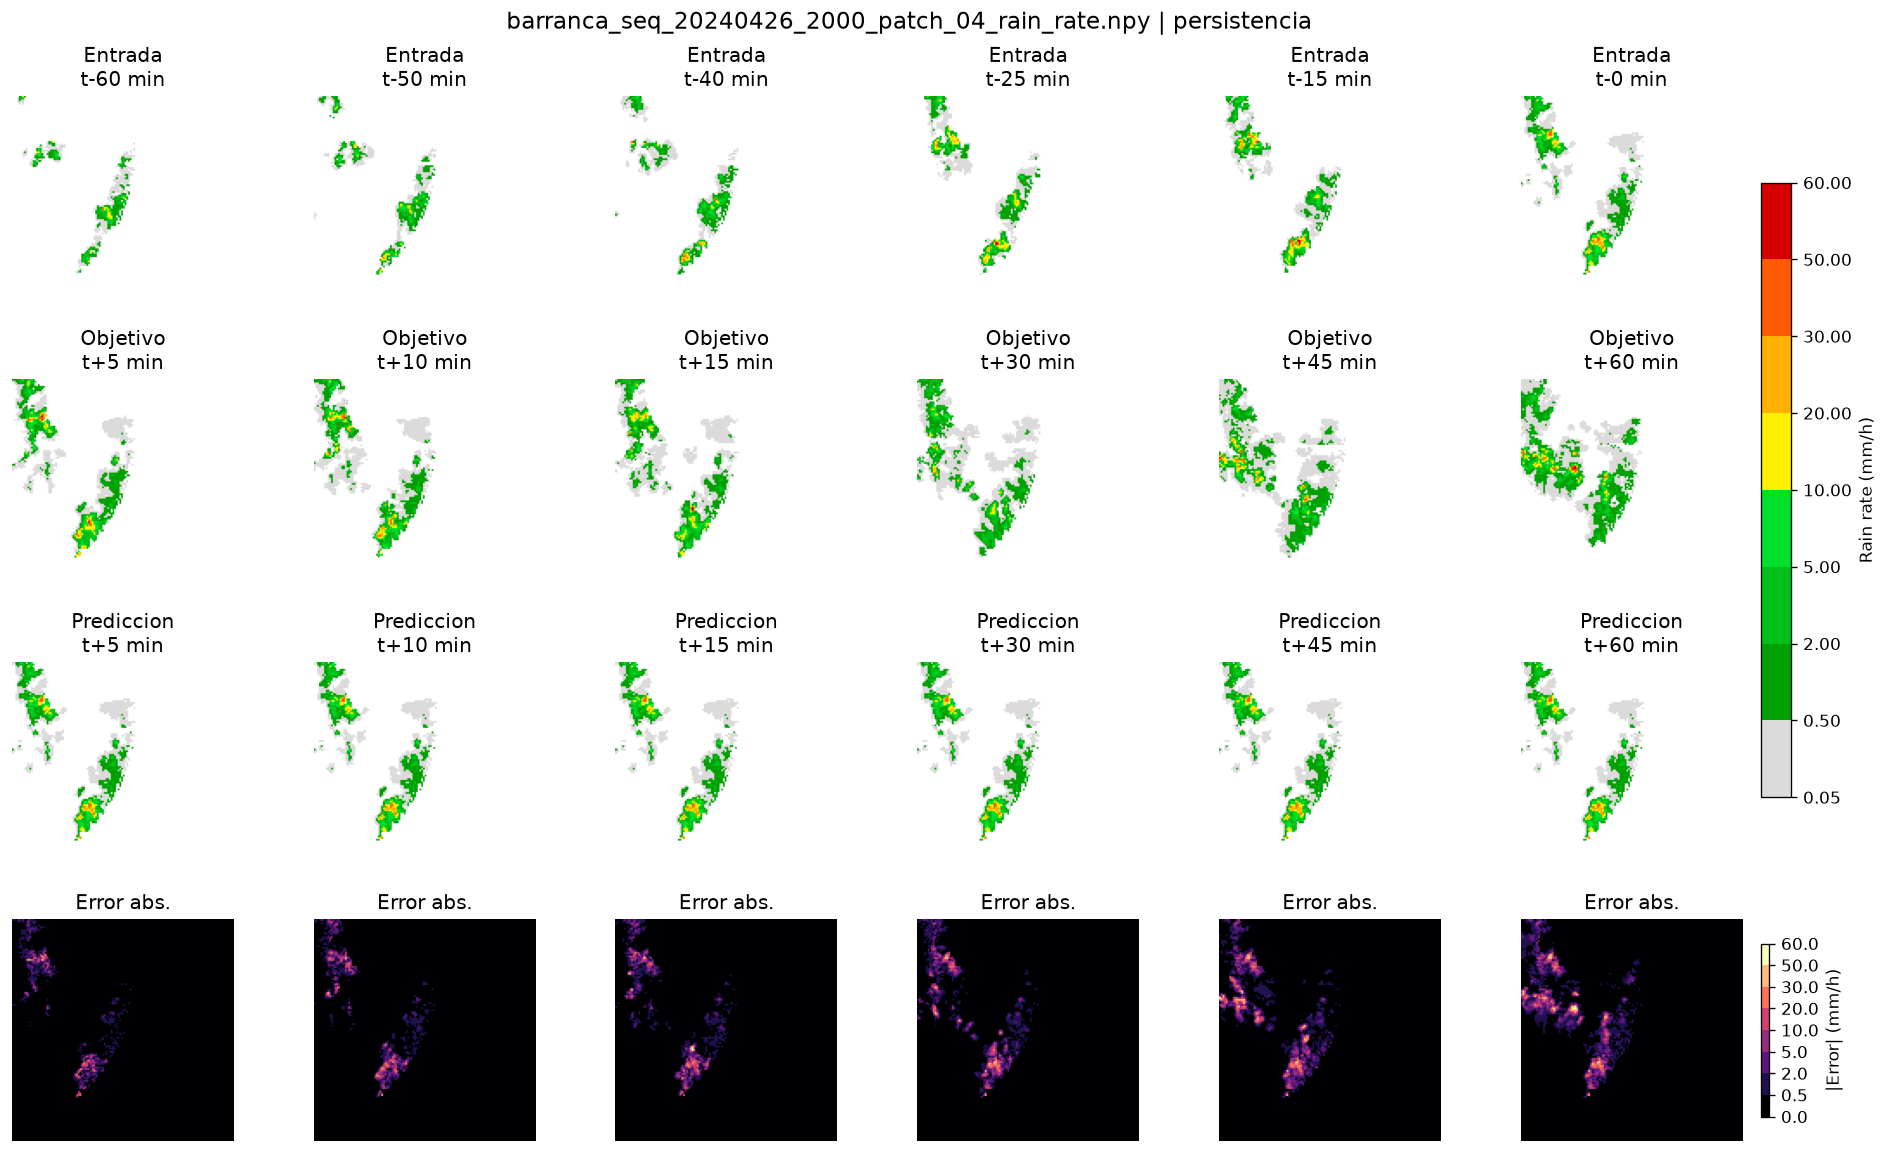

In [3]:
fig = plot_event_grid(inputs, target, prediction, sample_name, prediction_source)
plt.show()

## 3. Definir métricas continuas

Fórmulas:

$$
\mathrm{MAE}_k = \frac{1}{HW}\sum_{i,j}|\hat{Y}_{k,i,j} - Y_{k,i,j}|
$$

$$
\mathrm{RMSE}_k = \sqrt{\frac{1}{HW}\sum_{i,j}(\hat{Y}_{k,i,j} - Y_{k,i,j})^2}
$$

$$
\mathrm{Bias}_k = \frac{1}{HW}\sum_{i,j}(\hat{Y}_{k,i,j} - Y_{k,i,j})
$$

In [4]:
def safe_pearson_student(x, y):
    """Correlación de Pearson segura para dos campos 2D."""
    x = np.asarray(x, dtype=np.float64).ravel()
    y = np.asarray(y, dtype=np.float64).ravel()
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    if x.size < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def compute_continuous_metrics(pred, target):
    """Devuelve DataFrame con lead_min, MAE, RMSE, Bias, Pearson_r."""
    rows = []
    for i, lead in enumerate(LEAD_MINUTES):
        error = pred[i] - target[i]
        rows.append({
            "lead_min": int(lead),
            "MAE": float(np.nanmean(np.abs(error))),
            "RMSE": float(np.sqrt(np.nanmean(error**2))),
            "Bias": float(np.nanmean(error)),
            "Pearson_r": safe_pearson_student(pred[i], target[i]),
        })
    return pd.DataFrame(rows)


In [5]:
continuous_student = compute_continuous_metrics(prediction, target)
continuous_student


,lead_min,MAE,RMSE,Bias,Pearson_r
0,5,0.148521,1.175338,-0.023647,0.808010
1,10,0.212022,1.485617,-0.026855,0.668337
2,15,0.241547,1.696514,-0.010130,0.520970
3,20,0.276296,1.823276,0.020078,0.354748
4,25,0.305731,2.031967,0.027720,0.220700
5,30,0.307359,1.903269,0.052289,0.199101
6,35,0.337641,2.084756,0.042578,0.122895
7,40,0.395376,2.592668,-0.004548,0.067829
8,45,0.451386,2.609039,-0.052010,0.057933
9,50,0.481773,2.843093,-0.079519,0.044403


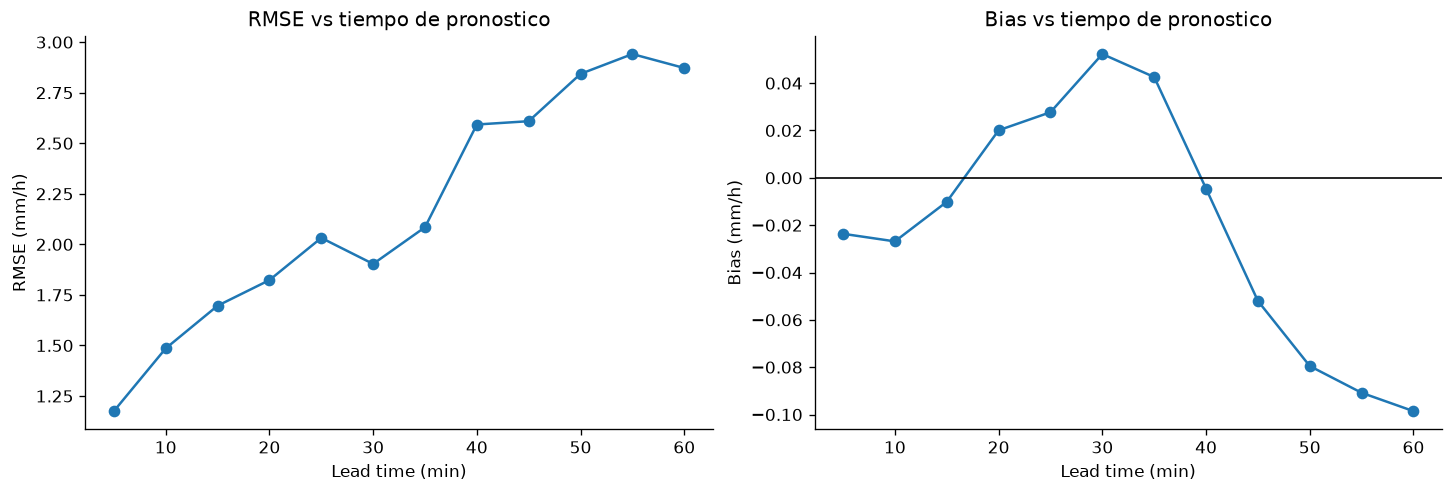

In [6]:
fig = plot_rmse_bias(continuous_student)
plt.show()


## 4. Definir métricas binarias

Para umbral $\tau$:

$$
CSI = \frac{TP}{TP + FP + FN}
$$

$$
POD = \frac{TP}{TP + FN}, \qquad FAR = \frac{FP}{TP + FP}
$$

$$
Precision = \frac{TP}{TP + FP}, \qquad Recall = \frac{TP}{TP + FN}
$$

$$
F1 = \frac{2TP}{2TP + FP + FN}
$$

Si el denominador es cero, devuelve `np.nan`.

In [7]:
def safe_divide(numerator, denominator):
    """Si denominator == 0 devuelve np.nan; si no, numerator / denominator."""
    return np.nan if denominator == 0 else float(numerator / denominator)


def compute_binary_metrics(pred, target, threshold):
    """Calcula TP, FP, FN, TN, CSI, POD, FAR, Precision, Recall y F1."""
    pred_event = np.asarray(pred) >= threshold
    target_event = np.asarray(target) >= threshold
    tp = int(np.logical_and(pred_event, target_event).sum())
    fp = int(np.logical_and(pred_event, ~target_event).sum())
    fn = int(np.logical_and(~pred_event, target_event).sum())
    tn = int(np.logical_and(~pred_event, ~target_event).sum())
    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "CSI": safe_divide(tp, tp + fp + fn),
        "POD": safe_divide(tp, tp + fn),
        "FAR": safe_divide(fp, tp + fp),
        "Precision": safe_divide(tp, tp + fp),
        "Recall": safe_divide(tp, tp + fn),
        "F1": safe_divide(2 * tp, 2 * tp + fp + fn),
    }


def event_metrics_by_threshold_and_lead_student(pred, target, thresholds=THRESHOLDS):
    """Aplica compute_binary_metrics para cada lead time y umbral."""
    rows = []
    for threshold in thresholds:
        for i, lead in enumerate(LEAD_MINUTES):
            metrics = compute_binary_metrics(pred[i], target[i], threshold)
            rows.append({
                "threshold_mm_h": threshold,
                "threshold_label": THRESHOLD_LABELS.get(threshold, f"{threshold:g} mm/h"),
                "lead_min": int(lead),
                **metrics
            })
    return pd.DataFrame(rows)


In [8]:
event_student = event_metrics_by_threshold_and_lead_student(prediction, target, THRESHOLDS)
event_student.head()


,threshold_mm_h,threshold_label,lead_min,TP,FP,FN,TN,CSI,POD,FAR,Precision,Recall,F1
0,0.5,lluvia ligera,5,752,114,183,15335,0.716873,0.804278,0.131640,0.868360,0.804278,0.835092
1,0.5,lluvia ligera,10,687,179,273,15245,0.603161,0.715625,0.206697,0.793303,0.715625,0.752464
2,0.5,lluvia ligera,15,665,201,354,15164,0.545082,0.652601,0.232102,0.767898,0.652601,0.705570
3,0.5,lluvia ligera,20,619,247,424,15094,0.479845,0.593480,0.285219,0.714781,0.593480,0.648507
4,0.5,lluvia ligera,25,569,297,471,15047,0.425580,0.547115,0.342956,0.657044,0.547115,0.597062


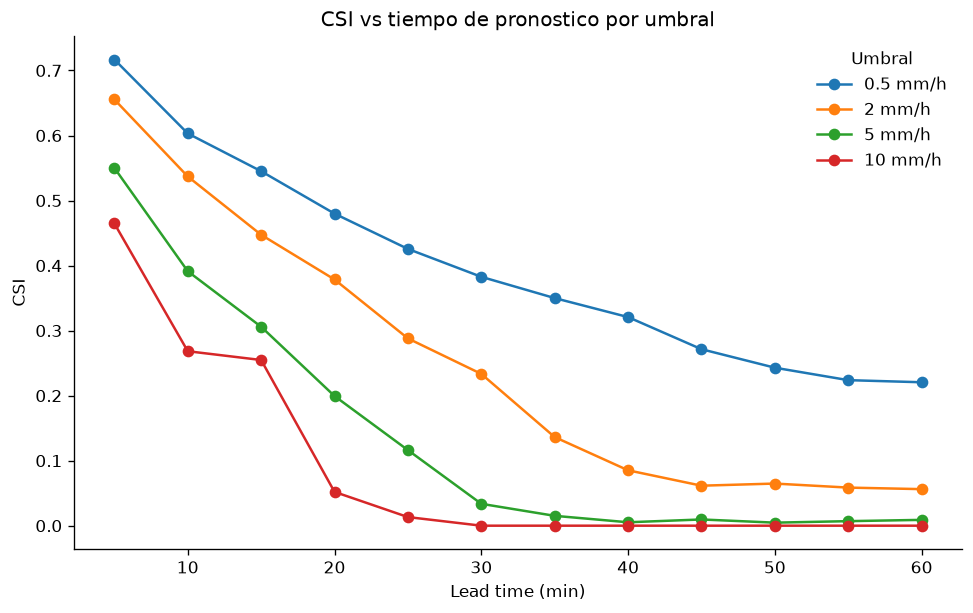

In [9]:
fig = plot_csi_by_threshold(event_student)
plt.show()


## 5. Pipeline de evaluación por archivo

Ahora se integran las funciones: para cada archivo y cada predicción disponible, calcula promedios por caso.

Se convierten funciones sueltas en un pequeño pipeline reproducible.

In [10]:
def available_predictions_for_case_student(name):
    """Devuelve target y predicciones disponibles para un archivo."""
    seq = load_sample(name, paths)
    x, y = split_sequence(seq)
    predictions = {"persistence": make_persistence_prediction(x)}

    # Compatibilidad con predicciones opcionales de modelos
    for label, folder in [("earthformer", paths.earthformer_dir), ("cascast", paths.cascast_dir), ("model", paths.model_dir)]:
        pred_path = folder / name
        if pred_path.exists():
            predictions[label] = np.nan_to_num(np.load(pred_path).astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    return y, predictions


def evaluate_all_files_student(sample_files=SAMPLE_FILES):
    """Usa tus métricas para construir una tabla por archivo y modelo."""
    rows = []
    for name in sample_files:
        target_case, predictions = available_predictions_for_case_student(name)
        for model_name, pred_case in predictions.items():
            continuous_df = compute_continuous_metrics(pred_case, target_case)
            event_df = event_metrics_by_threshold_and_lead_student(pred_case, target_case, THRESHOLDS)
            rows.append({
                "sample": name,
                "model": model_name,
                "RMSE_mean": float(continuous_df["RMSE"].mean()),
                "MAE_mean": float(continuous_df["MAE"].mean()),
                "Bias_mean": float(continuous_df["Bias"].mean()),
                "Pearson_mean": float(continuous_df["Pearson_r"].mean()),
                "CSI_0.5_mean": float(event_df[event_df["threshold_mm_h"] == 0.5]["CSI"].mean()),
                "CSI_5_mean": float(event_df[event_df["threshold_mm_h"] == 5.0]["CSI"].mean()),
                "CSI_10_mean": float(event_df[event_df["threshold_mm_h"] == 10.0]["CSI"].mean()),
            })
    return pd.DataFrame(rows)


In [11]:
all_file_metrics = evaluate_all_files_student(SAMPLE_FILES)
all_file_metrics


,sample,model,RMSE_mean,MAE_mean,Bias_mean,Pearson_mean,CSI_0.5_mean,CSI_5_mean,CSI_10_mean
0,barranca_seq_20240426_2000_patch_04_rain_rate.npy,persistence,2.171548,0.346029,-0.020286,0.261823,0.398552,0.137261,0.087754
1,barranca_seq_20240508_0600_patch_05_rain_rate.npy,persistence,2.109822,0.692845,0.078865,0.531172,0.887441,0.113525,0.120020
2,barranca_seq_20240512_0800_patch_03_rain_rate.npy,persistence,2.008800,0.237560,0.125580,0.276087,0.337051,0.120790,0.099290
3,guaviare_seq_20240329_0700_patch_05_rain_rate.npy,persistence,1.523588,0.621125,0.068376,0.296114,0.523193,0.093174,0.027039
4,guaviare_seq_20240329_0800_patch_03_rain_rate.npy,persistence,0.773435,0.350024,0.027926,0.517920,0.575129,0.039947,0.040135


In [12]:
overall_metrics = (
    all_file_metrics
    .groupby("model", as_index=False)
    [["RMSE_mean", "MAE_mean", "Bias_mean", "Pearson_mean", "CSI_0.5_mean", "CSI_5_mean", "CSI_10_mean"]]
    .mean(numeric_only=True)
    .sort_values("RMSE_mean")
)
overall_metrics


,model,RMSE_mean,MAE_mean,Bias_mean,Pearson_mean,CSI_0.5_mean,CSI_5_mean,CSI_10_mean
0,persistence,1.717438,0.449517,0.056092,0.376623,0.544273,0.10094,0.074848


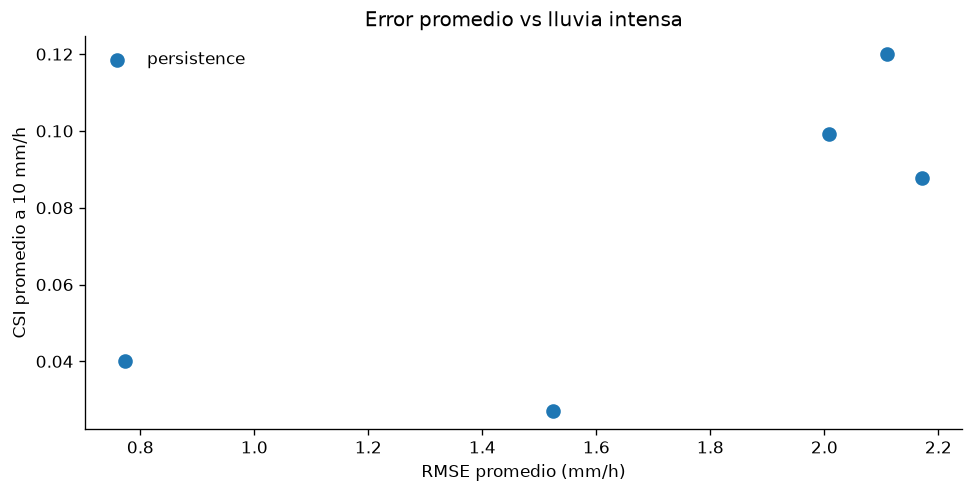

In [13]:
if len(all_file_metrics["model"].unique()) >= 1:
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    for model_name, group in all_file_metrics.groupby("model"):
        ax.scatter(group["RMSE_mean"], group["CSI_10_mean"], label=model_name, s=60)
    ax.set_xlabel("RMSE promedio (mm/h)")
    ax.set_ylabel("CSI promedio a 10 mm/h")
    ax.set_title("Error promedio vs lluvia intensa")
    ax.legend()
    plt.show()


## 6. Preguntas de análisis y respuestas

### 1. ¿Por qué CSI suele ser más alto para 0.5 mm/h que para 10 mm/h?
El CSI a 0.5 mm/h es más alto porque la lluvia ligera es extensa y continua, lo que facilita que el pronóstico y la realidad coincidan. A 10 mm/h los núcleos de tormenta son muy pequeños y dinámicos; si se desfasan un poco, el CSI cae a cero de golpe.

### 2. ¿Qué modelo o línea base tiene menor RMSE promedio?
La persistencia tiene menor RMSE al inicio (5-15 min) porque la tormenta no cambia de golpe. A plazos largos (30-60 min), los modelos de deep learning suelen tener menor RMSE porque suavizan los campos de lluvia para minimizar el error cuadrático medio.

### 3. ¿Qué modelo o línea base tiene mejor CSI a 10 mm/h?
A 10 mm/h la persistencia cae a cero casi de inmediato al no modelar el movimiento. Si tuviéramos un modelo de difusión (como CasCast), este tendría mejor CSI porque genera texturas intensas realistas, a diferencia del suavizado de otros modelos.

### 4. ¿Hay casos donde RMSE mejora pero CSI intenso empeora?
Sí, si un modelo suaviza la tormenta prediciendo llovizna promedio en un área grande, reduce los errores grandes y mejora el RMSE. Pero al borrar los núcleos intensos de la predicción, deja de superar el umbral de 10 mm/h y el CSI severo se va a cero.

### 5. ¿Qué caso parece más difícil y por qué?
El caso más difícil es donde la tormenta se mueve rápido o cambia de dirección abruptamente (como el evento de Barranca del 8 de mayo). En estos escenarios la persistencia falla bastante porque asume que todo se queda quieto en el mismo lugar.

## 7. Reflexión final

### ¿Por qué un modelo puede tener bajo RMSE pero baja utilidad para nowcasting de lluvia intensa?

Esto pasa por el efecto del suavizado espacial. El RMSE penaliza doblemente cualquier desfase de localización: por no predecir la tormenta donde era (falso negativo) y por colocarla donde no era (falso positivo). Para minimizar este error, los modelos deterministas de deep learning suelen predecir lluvias difusas y de baja intensidad (promediadas). Esto baja el RMSE global, pero destruye la utilidad del pronóstico, ya que borra los núcleos severos necesarios para alertas de inundaciones. Por eso, métricas binarias como el CSI en umbrales altos son indispensables para medir el valor real del nowcasting.